In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import os
import seaborn as sns 
from keras.models import Sequential , Model
from keras.layers import Dense,Flatten , Conv2D ,  Reshape , Input , Conv2DTranspose
from keras.layers import Activation, LeakyReLU, BatchNormalization, Dropout, Resizing
from tensorflow.keras  import layers
from keras.losses import BinaryCrossentropy
from tensorflow.keras.applications import VGG16
import random
import glob
# import albumentations as A
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers

print(tf.__version__)


2.21.0


In [50]:
train_pneumonia_dir = 'data/chest_xray/train/PNEUMONIA'
test_pneumonia_dir = 'data/chest_xray/test/PNEUMONIA'
valid_pneumonia_dir = 'data/chest_xray/val/PNEUMONIA'

In [51]:
target_size = (128,128)
batch_size = 32

In [52]:
def plot_multiple_img(img_matrix_list, title_list, ncols, main_title=""):
    fig, myaxes = plt.subplots(figsize=(20, 15), nrows=3, ncols=ncols, squeeze=False)
    fig.suptitle(main_title, fontsize = 30)
    fig.subplots_adjust(wspace=0.3)
    fig.subplots_adjust(hspace=0.3)
    for i, (img, title) in enumerate(zip(img_matrix_list, title_list)):
        myaxes[i // ncols][i % ncols].imshow(img)
        myaxes[i // ncols][i % ncols].set_title(title, fontsize=15)
    plt.show()

In [53]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)
        if img is not None:
            image_resized = cv2.resize(img, target_size)
            images.append(image_resized)
    return images

#Exploring the data

In [54]:
import glob
train_data = glob.glob('../data/chest_xray/train/**/*.*', recursive=True)
test_data = glob.glob('../data/chest_xray/test/**/*.*', recursive=True)
val_data = glob.glob('../data/chest_xray/val/**/*.*', recursive=True)

print(f"Training Set has: {len(train_data)} images")
print(f"Testing Set has: {len(test_data)} images")
print(f"Validation Set has: {len(val_data)} images")

print(train_data[:5])

Training Set has: 5216 images
Testing Set has: 624 images
Validation Set has: 16 images
['../data/chest_xray/train\\NORMAL\\IM-0115-0001.jpeg', '../data/chest_xray/train\\NORMAL\\IM-0117-0001.jpeg', '../data/chest_xray/train\\NORMAL\\IM-0119-0001.jpeg', '../data/chest_xray/train\\NORMAL\\IM-0122-0001.jpeg', '../data/chest_xray/train\\NORMAL\\IM-0125-0001.jpeg']


In [56]:
DIR = "../data/chest_xray/"
sets = ["train", "test", "val"]
all_pneumonia = []
all_normal = []

for cat in sets:
    path = os.path.join(DIR, cat)
    norm = glob.glob(os.path.join(path, "NORMAL/*.jpeg"))
    pneu = glob.glob(os.path.join(path, "PNEUMONIA/*.jpeg"))
    all_normal.extend(norm)
    all_pneumonia.extend(pneu)

print(f"Total Pneumonia Images: {len(all_pneumonia)}")
print(f"Total Normal Images: {len(all_normal)}")

Total Pneumonia Images: 4273
Total Normal Images: 1583


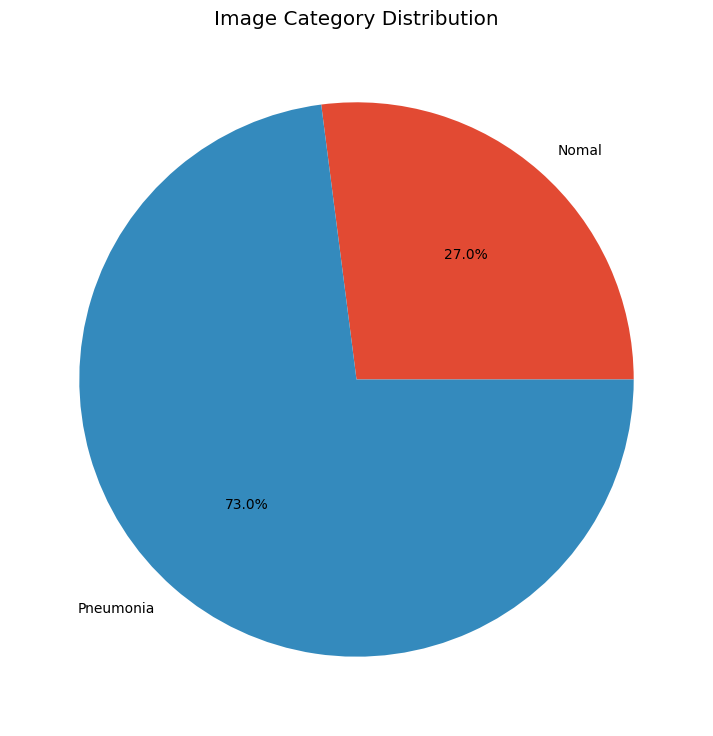

In [57]:
labels = ['Nomal', 'Pneumonia']
targets = [len(all_normal), len(all_pneumonia)]

plt.style.use("ggplot")
plt.figure(figsize=(16, 9))
plt.pie(x=targets, labels=labels, autopct="%1.1f%%")
plt.title("Image Category Distribution")
plt.show()